In [11]:
!pip install ultralytics albumentations --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 19.8 MB/s eta 0:00:00a 0:00:01


In [12]:
from ultralytics import YOLO
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [13]:
import shutil

src = "/kaggle/input/datasets/vishnudharsh/milestone-second/yolo_dataset"
dst = "/kaggle/working/yolo_dataset"

shutil.copytree(src, dst)

print("Dataset copied to working directory")

Dataset copied to working directory


In [14]:
import os

label_dir = "/kaggle/working/yolo_dataset/labels"

bad_files = []

for split in ["train", "val"]:
    folder = os.path.join(label_dir, split)

    for file in os.listdir(folder):
        path = os.path.join(folder, file)

        with open(path) as f:
            lines = f.readlines()

        for line in lines:
            values = list(map(float, line.strip().split()[1:]))

            if any(v < 0 or v > 1 for v in values):
                bad_files.append(path)

print("Corrupt label files:", len(bad_files))
print(bad_files[:10])

Corrupt label files: 25
['/kaggle/working/yolo_dataset/labels/train/5ee7d7e6df4cda91b44134754044751c.txt', '/kaggle/working/yolo_dataset/labels/train/f53c45bd444bfa9796ac5ce5489136c7.txt', '/kaggle/working/yolo_dataset/labels/train/f53c45bd444bfa9796ac5ce5489136c7.txt', '/kaggle/working/yolo_dataset/labels/train/2f3bb25eb6ae1a19b982c6ba56f725e2.txt', '/kaggle/working/yolo_dataset/labels/train/2f3bb25eb6ae1a19b982c6ba56f725e2.txt', '/kaggle/working/yolo_dataset/labels/train/2f3bb25eb6ae1a19b982c6ba56f725e2.txt', '/kaggle/working/yolo_dataset/labels/train/6ada6149fec45a9046dbfe15e3459ec8.txt', '/kaggle/working/yolo_dataset/labels/train/73677ea9100c2fc6b88ba7442c90bcf9.txt', '/kaggle/working/yolo_dataset/labels/train/2860567dbd5d3f2597072e0b0e45ccd6.txt', '/kaggle/working/yolo_dataset/labels/train/2860567dbd5d3f2597072e0b0e45ccd6.txt']


In [15]:
for file in bad_files:

    new_lines = []

    with open(file) as f:
        lines = f.readlines()

    for line in lines:
        parts = line.strip().split()

        cls = parts[0]
        coords = list(map(float, parts[1:]))

        coords = [min(max(c, 0), 1) for c in coords]

        new_lines.append(
            cls + " " + " ".join(map(str, coords)) + "\n"
        )

    with open(file, "w") as f:
        f.writelines(new_lines)

print("Corrupted labels fixed successfully")

Corrupted labels fixed successfully


In [16]:
import os

base = "/kaggle/working/yolo_dataset"

for split in ["train", "val"]:
    img_dir = os.path.join(base, "images", split)
    lbl_dir = os.path.join(base, "labels", split)

    images = len(os.listdir(img_dir))
    labels = len(os.listdir(lbl_dir))

    print(f"{split.upper()} IMAGES:", images)
    print(f"{split.upper()} LABELS:", labels)

TRAIN IMAGES: 388
TRAIN LABELS: 388
VAL IMAGES: 83
VAL LABELS: 83


In [11]:
!cat /kaggle/working/yolo_dataset/dataset.yaml

cat: /kaggle/working/yolo_dataset/dataset.yaml: No such file or directory


In [17]:
!ls /kaggle/working/yolo_dataset

images	labels


In [18]:
!ls /kaggle/input/datasets/vishnudharsh/milestone-second

dataset.yaml  __results___files  yolo26n.pt    yolov8s.pt
labels	      runs		 yolo_dataset


In [19]:
import shutil

shutil.copy(
    "/kaggle/input/datasets/vishnudharsh/milestone-second/dataset.yaml",
    "/kaggle/working/yolo_dataset/dataset.yaml"
)

print("dataset.yaml copied successfully")

dataset.yaml copied successfully


In [20]:
!ls /kaggle/working/yolo_dataset

dataset.yaml  images  labels


In [21]:
!cat /kaggle/working/yolo_dataset/dataset.yaml

names:
- Aortic enlargement
- Atelectasis
- Calcification
- Cardiomegaly
- Consolidation
- ILD
- Infiltration
- Lung Opacity
- Nodule/Mass
- Other lesion
- Pleural effusion
- Pleural thickening
- Pneumothorax
- Pulmonary fibrosis
nc: 14
path: /kaggle/working/yolo_dataset
test: images/test
train: images/train
val: images/val


In [22]:
import yaml

yaml_path = "/kaggle/working/yolo_dataset/dataset.yaml"

with open(yaml_path) as f:
    data = yaml.safe_load(f)

data["path"] = "/kaggle/working/yolo_dataset"

with open(yaml_path, "w") as f:
    yaml.dump(data, f)

print("dataset.yaml path updated")

dataset.yaml path updated


In [23]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/kaggle/working/yolo_dataset/dataset.yaml",
    epochs=30,
    imgsz=640,
    batch=8
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=30, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, p

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 11, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f9cb71454c0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [25]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

model.predict(
    source="/kaggle/working/yolo_dataset/images/val",
    save=True,
    conf=0.25
)


image 1/83 /kaggle/working/yolo_dataset/images/val/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 (no detections), 16.3ms
image 2/83 /kaggle/working/yolo_dataset/images/val/00aca42a24e4ea6066cca2546150c36e.jpg: 640x640 (no detections), 16.3ms
image 3/83 /kaggle/working/yolo_dataset/images/val/010018c93ed33ae56ed048ee54867e46.jpg: 640x640 (no detections), 16.3ms
image 4/83 /kaggle/working/yolo_dataset/images/val/038fc325ff4aa0a21c76d5dd7c740c89.jpg: 640x640 (no detections), 16.3ms
image 5/83 /kaggle/working/yolo_dataset/images/val/05e64c5b1e5f246ae6e8bc109e557bf4.jpg: 640x640 (no detections), 16.3ms
image 6/83 /kaggle/working/yolo_dataset/images/val/09f9a62fceffacc4d062a7fe24a626b8.jpg: 640x640 (no detections), 14.6ms
image 7/83 /kaggle/working/yolo_dataset/images/val/0b1b897b1e1e170f1b5fd7aeff553afa.jpg: 640x640 (no detections), 13.9ms
image 8/83 /kaggle/working/yolo_dataset/images/val/0cb91b8fe14a6d51725371b1956750a0.jpg: 640x640 (no detections), 13.9ms
image 9/83 /kaggle/working/yolo

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[254

In [26]:
model = YOLO("yolov8s.pt")

model.train(
    data="/kaggle/working/yolo_dataset/dataset.yaml",
    epochs=40,
    imgsz=640,
    batch=16,
    optimizer="SGD",
    lr0=0.001
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/dataset.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train2, nbs=64, nms=False, opset=None, optimize=False, optimizer=SGD, overlap_mask=True, patience=100,

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([ 0,  1,  2,  4,  5,  6,  7,  8,  9, 11, 13])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f9d14c3c230>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.

In [22]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

model.predict(
    source="/kaggle/working/yolo_dataset/images/val",
    save=True,
    conf=0.25
)


image 1/83 /kaggle/working/yolo_dataset/images/val/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 (no detections), 16.4ms
image 2/83 /kaggle/working/yolo_dataset/images/val/00aca42a24e4ea6066cca2546150c36e.jpg: 640x640 (no detections), 16.3ms
image 3/83 /kaggle/working/yolo_dataset/images/val/010018c93ed33ae56ed048ee54867e46.jpg: 640x640 (no detections), 16.3ms
image 4/83 /kaggle/working/yolo_dataset/images/val/038fc325ff4aa0a21c76d5dd7c740c89.jpg: 640x640 (no detections), 16.0ms
image 5/83 /kaggle/working/yolo_dataset/images/val/05e64c5b1e5f246ae6e8bc109e557bf4.jpg: 640x640 (no detections), 16.0ms
image 6/83 /kaggle/working/yolo_dataset/images/val/09f9a62fceffacc4d062a7fe24a626b8.jpg: 640x640 (no detections), 16.0ms
image 7/83 /kaggle/working/yolo_dataset/images/val/0b1b897b1e1e170f1b5fd7aeff553afa.jpg: 640x640 (no detections), 15.9ms
image 8/83 /kaggle/working/yolo_dataset/images/val/0cb91b8fe14a6d51725371b1956750a0.jpg: 640x640 (no detections), 15.9ms
image 9/83 /kaggle/working/yolo

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[254

In [27]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

model.predict(
    source="/kaggle/working/yolo_dataset/images/val",
    conf=0.01,
    save=True
)


image 1/83 /kaggle/working/yolo_dataset/images/val/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 3 Pleural thickenings, 12 Pulmonary fibrosiss, 16.3ms
image 2/83 /kaggle/working/yolo_dataset/images/val/00aca42a24e4ea6066cca2546150c36e.jpg: 640x640 6 Pleural thickenings, 10 Pulmonary fibrosiss, 16.3ms
image 3/83 /kaggle/working/yolo_dataset/images/val/010018c93ed33ae56ed048ee54867e46.jpg: 640x640 5 Pleural thickenings, 11 Pulmonary fibrosiss, 16.3ms
image 4/83 /kaggle/working/yolo_dataset/images/val/038fc325ff4aa0a21c76d5dd7c740c89.jpg: 640x640 5 Pleural thickenings, 14 Pulmonary fibrosiss, 16.3ms
image 5/83 /kaggle/working/yolo_dataset/images/val/05e64c5b1e5f246ae6e8bc109e557bf4.jpg: 640x640 7 Pleural thickenings, 21 Pulmonary fibrosiss, 16.3ms
image 6/83 /kaggle/working/yolo_dataset/images/val/09f9a62fceffacc4d062a7fe24a626b8.jpg: 640x640 6 Pleural thickenings, 10 Pulmonary fibrosiss, 16.3ms
image 7/83 /kaggle/working/yolo_dataset/images/val/0b1b897b1e1e170f1b5fd7aeff553afa.jpg: 640x

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[254

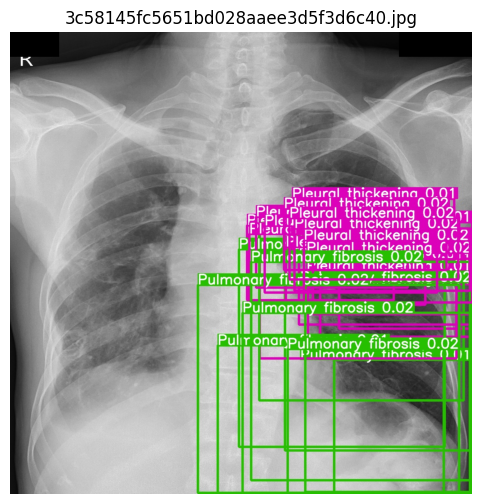

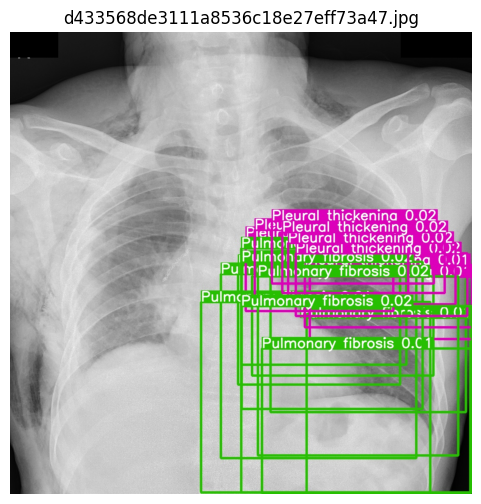

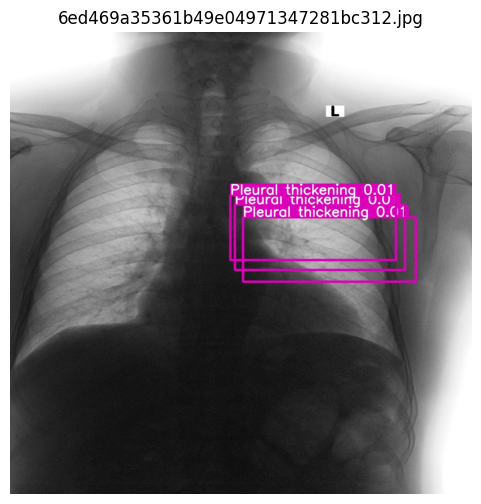

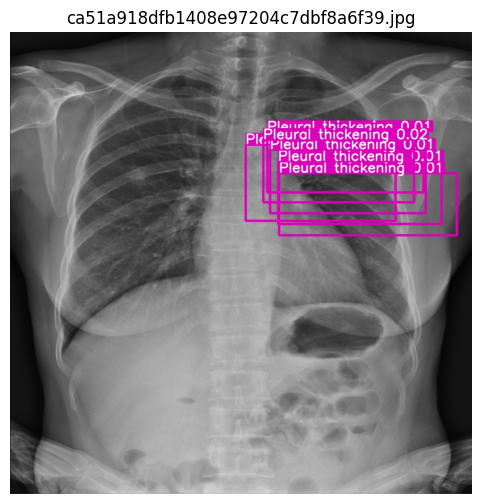

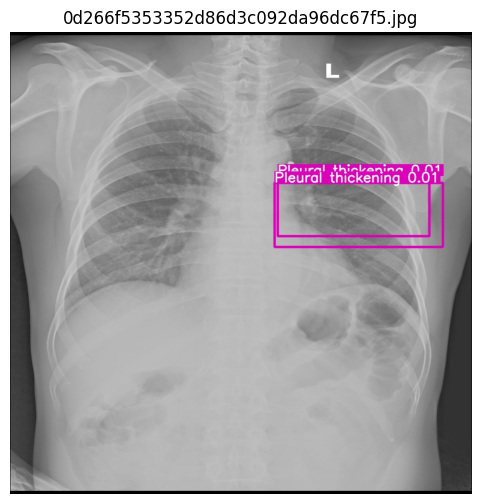

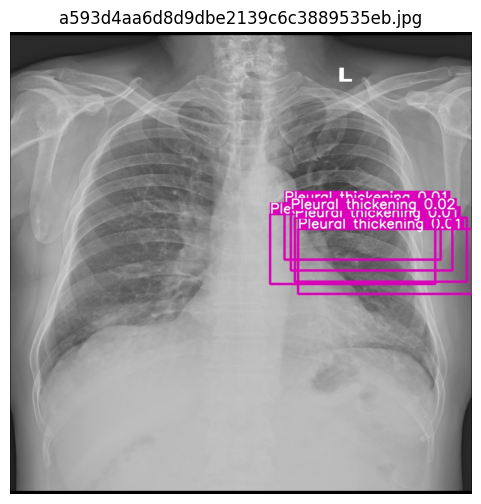

In [28]:
import os
import cv2
import matplotlib.pyplot as plt

pred_dir = "/kaggle/working/runs/detect/predict3"

images = os.listdir(pred_dir)[:6]  # show first 6 images

for img_name in images:
    img_path = os.path.join(pred_dir, img_name)

    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(img_name)
    plt.axis("off")
    plt.show()

In [29]:
from ultralytics import YOLO

# Load trained model
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# Run prediction with better thresholds
model.predict(
    source="/kaggle/working/yolo_dataset/images/val",
    
    conf=0.10,        # confidence threshold (filters weak predictions)
    iou=0.5,          # Non-Maximum Suppression threshold
    max_det=5,        # limit number of boxes per image
    
    save=True,        # save prediction images
    save_txt=False,   # no need to save label txt
    line_width=2
)


image 1/83 /kaggle/working/yolo_dataset/images/val/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 (no detections), 16.2ms
image 2/83 /kaggle/working/yolo_dataset/images/val/00aca42a24e4ea6066cca2546150c36e.jpg: 640x640 (no detections), 16.3ms
image 3/83 /kaggle/working/yolo_dataset/images/val/010018c93ed33ae56ed048ee54867e46.jpg: 640x640 (no detections), 16.3ms
image 4/83 /kaggle/working/yolo_dataset/images/val/038fc325ff4aa0a21c76d5dd7c740c89.jpg: 640x640 (no detections), 16.3ms
image 5/83 /kaggle/working/yolo_dataset/images/val/05e64c5b1e5f246ae6e8bc109e557bf4.jpg: 640x640 (no detections), 16.3ms
image 6/83 /kaggle/working/yolo_dataset/images/val/09f9a62fceffacc4d062a7fe24a626b8.jpg: 640x640 (no detections), 16.3ms
image 7/83 /kaggle/working/yolo_dataset/images/val/0b1b897b1e1e170f1b5fd7aeff553afa.jpg: 640x640 (no detections), 16.3ms
image 8/83 /kaggle/working/yolo_dataset/images/val/0cb91b8fe14a6d51725371b1956750a0.jpg: 640x640 (no detections), 16.3ms
image 9/83 /kaggle/working/yolo

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[254

In [27]:
from ultralytics import YOLO

model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

model.predict(
    source="/kaggle/working/yolo_dataset/images/val",
    conf=0.03,   # balanced threshold
    iou=0.5,
    max_det=5,
    save=True
)


image 1/83 /kaggle/working/yolo_dataset/images/val/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 (no detections), 15.9ms
image 2/83 /kaggle/working/yolo_dataset/images/val/00aca42a24e4ea6066cca2546150c36e.jpg: 640x640 (no detections), 15.9ms
image 3/83 /kaggle/working/yolo_dataset/images/val/010018c93ed33ae56ed048ee54867e46.jpg: 640x640 (no detections), 15.9ms
image 4/83 /kaggle/working/yolo_dataset/images/val/038fc325ff4aa0a21c76d5dd7c740c89.jpg: 640x640 (no detections), 15.9ms
image 5/83 /kaggle/working/yolo_dataset/images/val/05e64c5b1e5f246ae6e8bc109e557bf4.jpg: 640x640 (no detections), 15.9ms
image 6/83 /kaggle/working/yolo_dataset/images/val/09f9a62fceffacc4d062a7fe24a626b8.jpg: 640x640 (no detections), 15.9ms
image 7/83 /kaggle/working/yolo_dataset/images/val/0b1b897b1e1e170f1b5fd7aeff553afa.jpg: 640x640 (no detections), 15.9ms
image 8/83 /kaggle/working/yolo_dataset/images/val/0cb91b8fe14a6d51725371b1956750a0.jpg: 640x640 (no detections), 15.0ms
image 9/83 /kaggle/working/yolo

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 keypoints: None
 masks: None
 names: {0: 'Aortic enlargement', 1: 'Atelectasis', 2: 'Calcification', 3: 'Cardiomegaly', 4: 'Consolidation', 5: 'ILD', 6: 'Infiltration', 7: 'Lung Opacity', 8: 'Nodule/Mass', 9: 'Other lesion', 10: 'Pleural effusion', 11: 'Pleural thickening', 12: 'Pneumothorax', 13: 'Pulmonary fibrosis'}
 obb: None
 orig_img: array([[[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        [[255, 255, 255],
         [255, 255, 255],
         [255, 255, 255],
         ...,
         [255, 255, 255],
         [255, 255, 255],
         [255, 255, 255]],
 
        ...,
 
        [[254

In [30]:
from ultralytics import YOLO

# Load best trained model
model = YOLO("/kaggle/working/runs/detect/train/weights/best.pt")

# Run prediction with balanced visualization settings
results = model.predict(
    source="/kaggle/working/yolo_dataset/images/val",
    
    conf=0.005,     # allow very weak predictions
    iou=0.5,        # NMS threshold
    max_det=3,      # limit boxes per image
    
    save=True,
    save_txt=False
)


image 1/83 /kaggle/working/yolo_dataset/images/val/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 1 Pleural thickening, 2 Pulmonary fibrosiss, 16.3ms
image 2/83 /kaggle/working/yolo_dataset/images/val/00aca42a24e4ea6066cca2546150c36e.jpg: 640x640 2 Pleural thickenings, 1 Pulmonary fibrosis, 16.3ms
image 3/83 /kaggle/working/yolo_dataset/images/val/010018c93ed33ae56ed048ee54867e46.jpg: 640x640 1 Pleural thickening, 2 Pulmonary fibrosiss, 16.2ms
image 4/83 /kaggle/working/yolo_dataset/images/val/038fc325ff4aa0a21c76d5dd7c740c89.jpg: 640x640 1 Pleural thickening, 2 Pulmonary fibrosiss, 16.2ms
image 5/83 /kaggle/working/yolo_dataset/images/val/05e64c5b1e5f246ae6e8bc109e557bf4.jpg: 640x640 1 Pleural thickening, 2 Pulmonary fibrosiss, 16.3ms
image 6/83 /kaggle/working/yolo_dataset/images/val/09f9a62fceffacc4d062a7fe24a626b8.jpg: 640x640 2 Pleural thickenings, 1 Pulmonary fibrosis, 16.3ms
image 7/83 /kaggle/working/yolo_dataset/images/val/0b1b897b1e1e170f1b5fd7aeff553afa.jpg: 640x640 2 Pleura

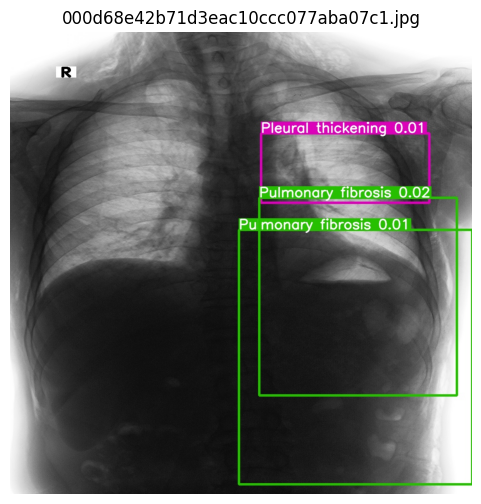

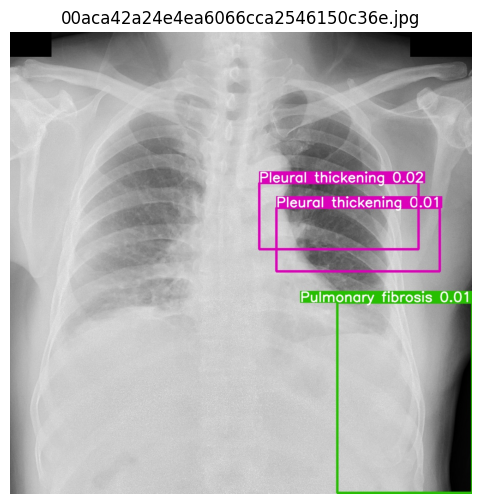

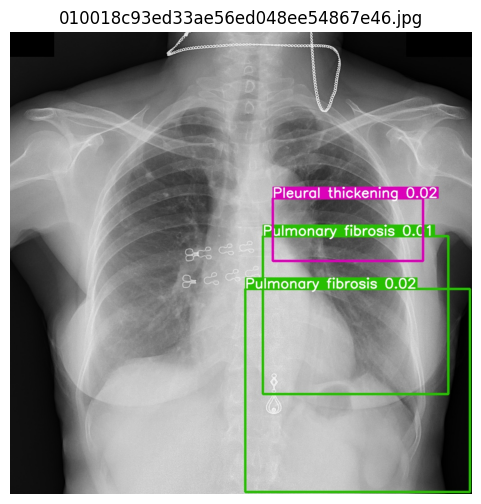

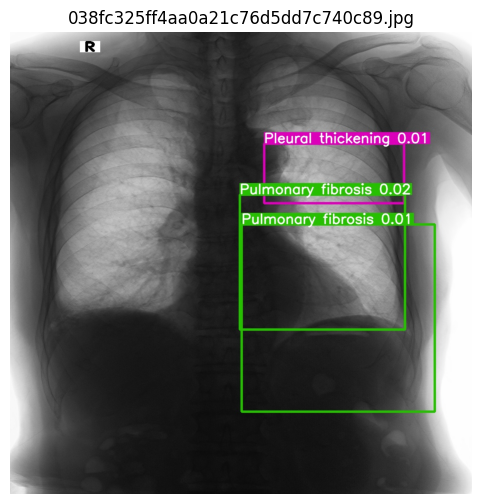

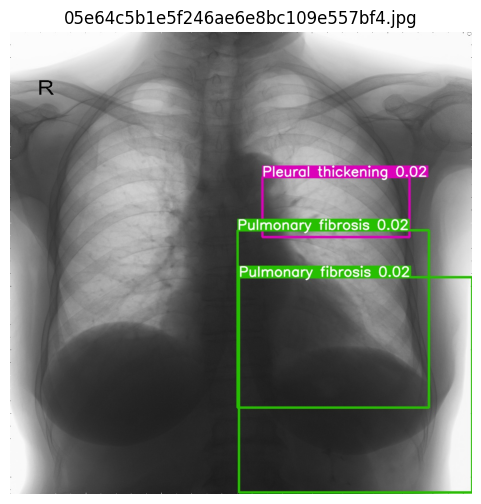

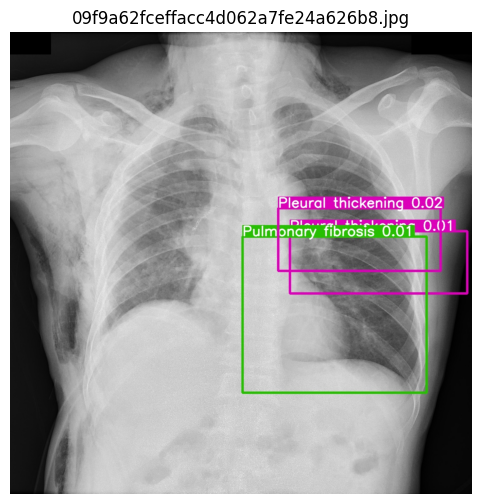

In [32]:
import os
import cv2
import matplotlib.pyplot as plt

pred_dir = "/kaggle/working/runs/detect/predict5"

files = sorted(os.listdir(pred_dir))[:6]

for f in files:
    img = cv2.imread(os.path.join(pred_dir, f))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(6,6))
    plt.imshow(img)
    plt.title(f)
    plt.axis("off")
    plt.show()

In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8s.pt")

model.train(
    data="/kaggle/working/yolo_dataset/dataset.yaml",
    
    epochs=40,
    imgsz=640,
    batch=8,

    fliplr=0.5,
    degrees=10,
    translate=0.1,
    scale=0.2,
    hsv_v=0.2,
    
    name="train_aug"
)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/yolo_dataset/dataset.yaml, degrees=10, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=40, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.2, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8s.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train_aug, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100

In [3]:
import torch
import torchvision.models as models
import torch.nn as nn

In [9]:
import torch
import torchvision.models as models
import torch.nn as nn

# Load EfficientNet
model = models.efficientnet_b0(weights=None)

# Correct number of classes (15)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 15)

# Load saved weights
state_dict = torch.load(
"/kaggle/input/datasets/vishnudharsh/classificationmodel-second/classification_model.pth",
map_location="cpu"
)

model.load_state_dict(state_dict)

model.eval()

print("Model loaded successfully")

Model loaded successfully


In [10]:
print(model.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=15, bias=True)
)


In [33]:
!pip install grad-cam

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 57.4 MB/s eta 0:00:0000:0100:01
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for grad-cam: filename=grad_cam-1.5.5-py3-none-any.whl size=44286 sha256=0f462bd5ecb5b0418c3f380e274b94dfc88344918fee43a0b9e4e737e4eb06e0
  Stored in directory: /root/.cache/pip/wheels/fb/3b/09/2afc520f3d69bc26ae6bd87416759c820a3f7d05c1a077bbf6
Successfully built grad-cam


In [38]:
import torch
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt

from torchvision import transforms
from torchvision.models import efficientnet_b0

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

In [39]:
num_classes = 15

model = efficientnet_b0(weights=None)

model.classifier[1] = torch.nn.Linear(
    model.classifier[1].in_features,
    num_classes
)

model.load_state_dict(torch.load("/kaggle/input/datasets/vishnudharsh/classificationmodel-second/classification_model.pth", map_location="cpu"))

model.eval()

EfficientNet(
  (features): Sequential(
    (0): Conv2dNormActivation(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): SiLU(inplace=True)
    )
    (1): Sequential(
      (0): MBConv(
        (block): Sequential(
          (0): Conv2dNormActivation(
            (0): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), groups=32, bias=False)
            (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
            (2): SiLU(inplace=True)
          )
          (1): SqueezeExcitation(
            (avgpool): AdaptiveAvgPool2d(output_size=1)
            (fc1): Conv2d(32, 8, kernel_size=(1, 1), stride=(1, 1))
            (fc2): Conv2d(8, 32, kernel_size=(1, 1), stride=(1, 1))
            (activation): SiLU(inplace=True)
            (scale_activation): Sigmoid()
          )
          (2): Conv2dNormActivat

In [40]:
target_layer = model.features[-1]

In [41]:
transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
])

In [43]:
import os
import random
from PIL import Image

val_folder = "yolo_dataset/images/val"

img_path = os.path.join(val_folder, random.choice(os.listdir(val_folder)))

print("Selected Image:", img_path)

image = Image.open(img_path).convert("RGB")

input_tensor = transform(image).unsqueeze(0)

rgb_img = np.array(image.resize((224,224))) / 255.0

Selected Image: yolo_dataset/images/val/85cfc59f138f490784170dbaeb0112a7.jpg


In [44]:
cam = GradCAM(model=model, target_layers=[target_layer])

targets = None  # Automatically uses predicted class

grayscale_cam = cam(input_tensor=input_tensor, targets=targets)

grayscale_cam = grayscale_cam[0]

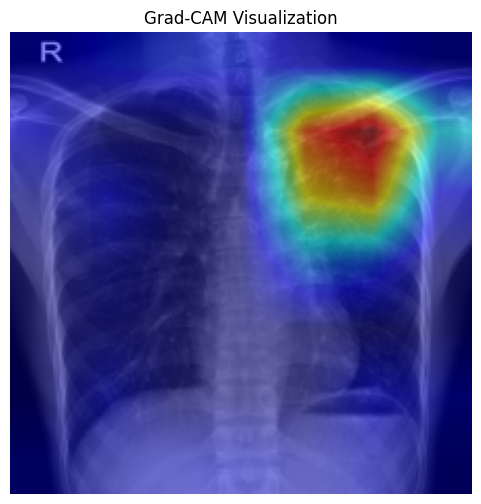

In [45]:
visualization = show_cam_on_image(rgb_img, grayscale_cam, use_rgb=True)

plt.figure(figsize=(6,6))
plt.imshow(visualization)
plt.axis("off")
plt.title("Grad-CAM Visualization")
plt.show()

In [46]:
cv2.imwrite("gradcam_result.png", visualization)

True

In [49]:
from ultralytics import YOLO

yolo_model = YOLO("runs/detect/train_transfer/weights/best.pt")

FileNotFoundError: [Errno 2] No such file or directory: 'runs/detect/train_transfer/weights/best.pt'

In [50]:
import os

print(os.listdir("runs/detect"))

['predict', 'predict3', 'predict2', 'predict4', 'predict5', 'train2', 'train']


In [52]:
import os
print(os.listdir("runs/detect/train2/weights"))

['best.pt', 'last.pt']


In [53]:
from ultralytics import YOLO

yolo_model = YOLO("runs/detect/train2/weights/best.pt")

In [54]:
results = yolo_model.predict(
    source="yolo_dataset/images/val",
    conf=0.25,
    save=True
)


image 1/83 /kaggle/working/yolo_dataset/images/val/000d68e42b71d3eac10ccc077aba07c1.jpg: 640x640 (no detections), 16.3ms
image 2/83 /kaggle/working/yolo_dataset/images/val/00aca42a24e4ea6066cca2546150c36e.jpg: 640x640 (no detections), 16.3ms
image 3/83 /kaggle/working/yolo_dataset/images/val/010018c93ed33ae56ed048ee54867e46.jpg: 640x640 (no detections), 16.4ms
image 4/83 /kaggle/working/yolo_dataset/images/val/038fc325ff4aa0a21c76d5dd7c740c89.jpg: 640x640 (no detections), 16.3ms
image 5/83 /kaggle/working/yolo_dataset/images/val/05e64c5b1e5f246ae6e8bc109e557bf4.jpg: 640x640 (no detections), 16.3ms
image 6/83 /kaggle/working/yolo_dataset/images/val/09f9a62fceffacc4d062a7fe24a626b8.jpg: 640x640 (no detections), 13.9ms
image 7/83 /kaggle/working/yolo_dataset/images/val/0b1b897b1e1e170f1b5fd7aeff553afa.jpg: 640x640 (no detections), 13.7ms
image 8/83 /kaggle/working/yolo_dataset/images/val/0cb91b8fe14a6d51725371b1956750a0.jpg: 640x640 (no detections), 13.7ms
image 9/83 /kaggle/working/yolo

In [48]:
results = model.predict(
    source="yolo_dataset/images/val",
    conf=0.25,
    save=True
)

AttributeError: 'EfficientNet' object has no attribute 'predict'

In [55]:
metrics = yolo_model.val()
print(metrics)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2878.8±675.5 MB/s, size: 292.5 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 83 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 83/83 17.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.4it/s 2.5s0.4s
                   all         83        239    0.00281      0.158    0.00824    0.00322
    Aortic enlargement          4          8          0          0          0          0
           Atelectasis          5          9     0.0112      0.111     0.0433     0.0216
         Calcification          8         13          0          0          0          0
         Consolidation          2          4    0.00541       0.25    0.00516     0.0025
                   ILD          1          1          0          0          0          0
          Infiltration         

In [58]:
y_true = []
y_pred = []

In [59]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

val_dataset = ImageFolder("classification_dataset/val", transform=transform)

val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

FileNotFoundError: [Errno 2] No such file or directory: 'classification_dataset/val'

In [60]:
import os
print(os.listdir())

['gradcam_result.png', 'yolo_dataset', 'yolo26n.pt', 'yolov8s.pt', '.virtual_documents', 'runs']


In [62]:
torch.save(model.state_dict(), "classification_model.pth")

In [63]:
import shutil

shutil.make_archive("yolo_dataset", 'zip', "yolo_dataset")

'/kaggle/working/yolo_dataset.zip'

In [64]:
import shutil

shutil.make_archive("detection_examples", 'zip', "runs/detect/predict5")

'/kaggle/working/detection_examples.zip'

In [61]:
metrics = yolo_model.val()
print(metrics)

Ultralytics 8.4.23 🚀 Python-3.12.12 torch-2.9.0+cu126 CUDA:0 (Tesla T4, 14913MiB)
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 3018.4±966.8 MB/s, size: 240.8 KB)
val: Scanning /kaggle/working/yolo_dataset/labels/val.cache... 83 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 83/83 34.8Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 6/6 2.5it/s 2.4s0.4s
                   all         83        239    0.00281      0.158    0.00824    0.00322
    Aortic enlargement          4          8          0          0          0          0
           Atelectasis          5          9     0.0112      0.111     0.0433     0.0216
         Calcification          8         13          0          0          0          0
         Consolidation          2          4    0.00541       0.25    0.00516     0.0025
                   ILD          1          1          0          0          0          0
          Infiltration         

In [56]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

NameError: name 'y_true' is not defined